# Problem statement: we have patient data along with which drug is prescribed to him/her based on features like :
1.age
2.bp
3.Gender
4.cholestrol
5.Na_k
Bulid a ML model to predict which drug will a patient take based on following features
1.age=32
2.bp=NORMAL
3.Gender=M
4.cholestrol=HIGH
5.Na_k=14.5


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


In [ ]:
df=pd.read_csv('/content/Drug_Medicine.csv')

In [ ]:
df

,Age,Gender,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Gender       200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
df.shape

(200, 6)

In [ ]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


# Finding is there any null value

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


# Find any duplicated value

In [ ]:
df.duplicated().sum()


np.int64(0)

# divide columns based on datatype

In [ ]:
categorical_column=df.select_dtypes(include=['object']).columns
numerical_column=df.select_dtypes(exclude=['object']).columns

In [ ]:
categorical_column

Index(['Gender', 'BP', 'Cholesterol', 'Drug'], dtype='object')

In [ ]:
numerical_column

Index(['Age', 'Na_to_K'], dtype='object')

In [ ]:
for col in categorical_column:
  print(df[col].value_counts())

Gender
M    104
F     96
Name: count, dtype: int64
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


# Outlier Detection

In [ ]:
def remove_outliers(df, column):
  q1=df[column].quantile(0.25)
  q3=df[column].quantile(0.75)
  IQR= q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  return df[(df[column]>=lower_bound) & (df[column]<=upper_bound)]

In [ ]:
for col in numerical_column:
  df=remove_outliers(df,col)

In [ ]:
df.shape

(192, 6)

# univariant analysis

# plot for na_to_k

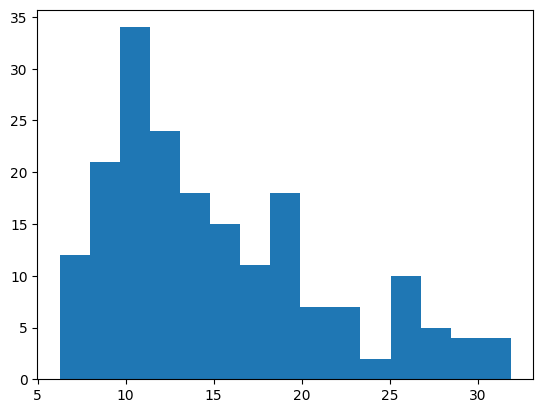

In [ ]:
plt.hist(df["Na_to_K"],bins=15)
plt.show()

# plot for age

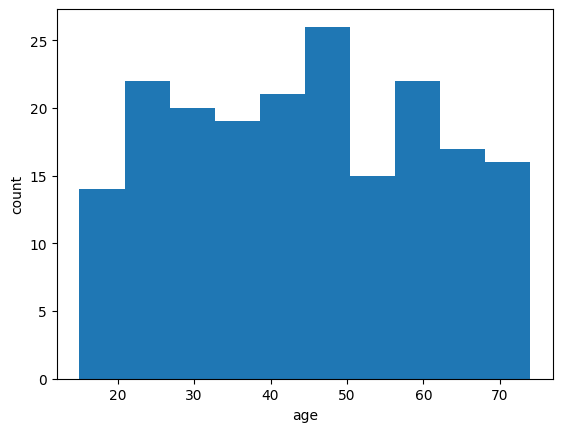

In [ ]:
plt.hist(df["Age"],bins=10)
plt.xlabel("age")
plt.ylabel("count")
plt.show()

# plot for Cholesterol

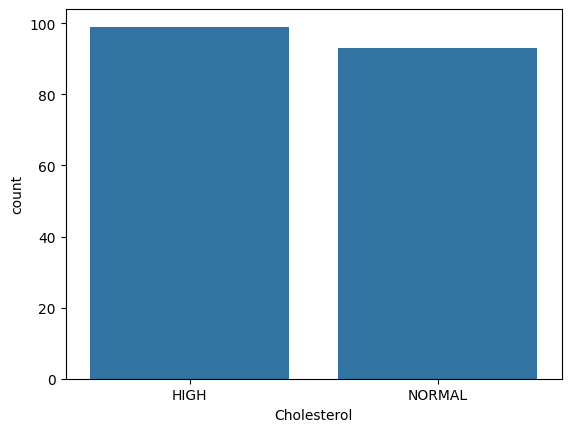

In [ ]:
sns.countplot(x='Cholesterol',data=df)
plt.show()

# bivaiance analysis heatmap for cloumns

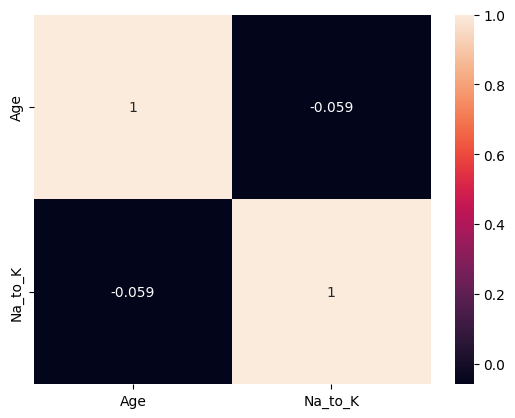

In [ ]:
df_num=df[numerical_column].corr()
sns.heatmap(df_num,annot=True)
plt.show()

# we requried label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
le_d={}

In [ ]:
for col in categorical_column:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col]=le


In [ ]:
le_d

{'Gender': LabelEncoder(),
 'BP': LabelEncoder(),
 'Cholesterol': LabelEncoder(),
 'Drug': LabelEncoder()}

In [ ]:
df

,Age,Gender,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4
...,...,...,...,...,...,...
195,56,0,1,0,11.567,2
196,16,1,1,0,12.006,2
197,52,1,2,0,9.894,3
198,23,1,2,1,14.020,3


# Model_buliding

In [ ]:
X=df.drop('Drug',axis=1)
y=df['Drug']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((153, 5), (39, 5), (153,), (39,))

# Import multiple models

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
models={
    'GaussianNB':GaussianNB(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier()
}

# model training

In [ ]:
models['GaussianNB'].fit(X_train,y_train)
models["DecisionTreeClassifier"].fit(X_train,y_train)
models["RandomForestClassifier"].fit(X_train,y_train)


RandomForestClassifier()

# model evaluation

In [ ]:
nb_pred=models['GaussianNB'].predict(X_test)
dt_pred=models['DecisionTreeClassifier'].predict(X_test)
rf_pred=models['RandomForestClassifier'].predict(X_test)

# Compare values for y_test vs y_pred

# Confusion Matrix

In [ ]:
print("confusion matrix for GaussianNB")
print(metrics.confusion_matrix(y_test,nb_pred))
print("confusion matrix for DecisionTreeClassifier")
print(metrics.confusion_matrix(y_test,dt_pred))
print("confusion matrix for RandomForestClassifier")
print(metrics.confusion_matrix(y_test,rf_pred))

confusion matrix for GaussianNB
[[ 7  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0 11  1]
 [ 4  1  1  0 10]]
confusion matrix for DecisionTreeClassifier
[[ 7  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0 12  0]
 [ 0  0  0  0 16]]
confusion matrix for RandomForestClassifier
[[ 7  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0 12  0]
 [ 0  0  0  0 16]]


In [ ]:
nb_acc=metrics.accuracy_score(y_test,nb_pred)
dt_acc=metrics.accuracy_score(y_test,dt_pred)
rf_acc=metrics.accuracy_score(y_test,rf_pred)

In [ ]:
print("accuracy for GaussianNB :",nb_acc)
print("accuracy for DecisionTreeClassifier :",dt_acc)
print("accuracy for RandomForestClassifier :",rf_acc)


accuracy for GaussianNB : 0.8205128205128205
accuracy for DecisionTreeClassifier : 1.0
accuracy for RandomForestClassifier : 1.0


In [ ]:
best_model=models["RandomForestClassifier"]

In [ ]:
new_data1={'Age':32,
'Gender':'M',
'BP':'NORMAL',
'Cholesterol':'HIGH',
'Na_to_K':14.5}




In [ ]:
new_data=pd.DataFrame(new_data1,index=[0])

In [ ]:
new_data

,Age,Gender,BP,Cholesterol,Na_to_K
0,32,M,NORMAL,HIGH,14.5


In [ ]:
#pass the encoder values for encoding
new_data['BP']=le_d['BP'].transform(new_data['BP'])
new_data['Gender']=le_d['Gender'].transform(new_data['Gender'])
new_data['Cholesterol']=le_d['Cholesterol'].transform(new_data['Cholesterol'])

In [ ]:
new_data

,Age,Gender,BP,Cholesterol,Na_to_K
0,32,1,2,0,14.5


In [ ]:
#pass above new data to best model
prediction=best_model.predict(new_data)

In [ ]:
prediction

array([3])

# in encoding time we also encode drug[output column] so we need to inverse transform it to get actual categorical value

In [ ]:
le_d['Drug'].inverse_transform(prediction)

array(['drugX'], dtype=object)